# Testing Feature Engineering

I was able to run this code on an SCF cluster node in this jupyter notebook by following the instructions at this link:
https://computing.stat.berkeley.edu/access/vscode-remote-ssh/#connect-to-an-scf-cluster-node

In [1]:
library(tidyverse)
od_data <- read_csv("../data/od-data.csv")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 67770440 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): origin, destination
dbl  (2): hour, ridership
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Adding Features Mentioned in Previous EDA's

Since were going to be adding columns, let's check the size of the data object now.

In [2]:
format(object.size(od_data), units = "GB")

[1] "2.5 Gb"

Let's start by adding on the basic features from previous discussions

In [3]:
od_data <- od_data |> mutate(post_covid = if_else(date > ymd("2020-03-19"), 1, 0),
                            day = case_when(wday(date) %in% seq(2, 6) ~ "weekday",
                                            wday(date) == 1 ~ "sunday",
                                            wday(date) == 7 ~ "saturday")
                        )

Let's calculate some basic statistics grouped by our covid indicator and day variable.

In [4]:
od_data |> 
    group_by(post_covid, day) |>
    summarize(count = n(), median = median(ridership), mean = mean(ridership), sd = sd(ridership))

`summarise()` has grouped output by 'post_covid'. You can override using the
`.groups` argument.


post_covid,day,count,median,mean,sd
<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>
0,saturday,2842651,3,6.663028,12.622526
0,sunday,2425078,2,5.555799,11.226489
0,weekday,17058977,4,13.353914,35.826595
1,saturday,5692795,2,4.012325,6.665476
1,sunday,4830493,2,3.527505,5.818969
1,weekday,34920446,2,5.523402,10.962697


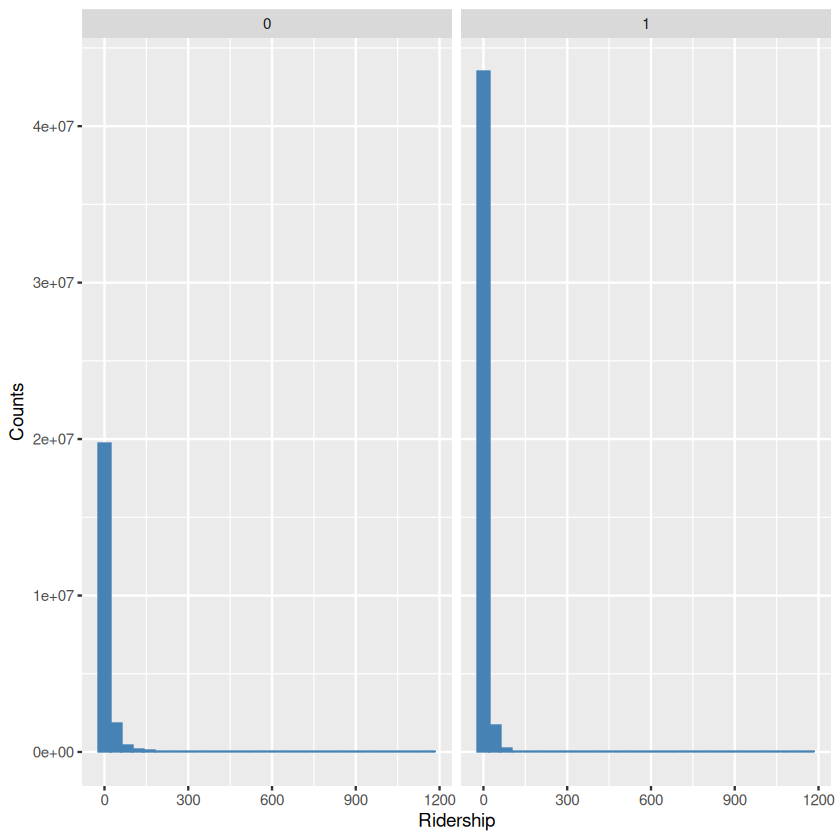

In [5]:
od_data |> 
    ggplot(aes(x = ridership)) + 
        geom_histogram(bins = 30, color = "steelblue", fill = "steelblue") + 
        labs(x = "Ridership",
            y = "Counts") + 
        facet_wrap(~ post_covid)

Let's look at the days and OD pairs with the max ridership. The one below is what we saw earlier.

In [6]:
od_data |>
    filter(post_covid == 0) |>
    slice_max(ridership)

date,hour,origin,destination,ridership,post_covid,day
<date>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>
2018-08-24,23,COLS,DUBL,1165,0,weekday


This one is pretty funny. This is the day a person went into the transbay tube and stopped BART service for over an hour. These are people getting on at Embarcadero, realizing they can't go anywhere, and getting off at the same station.

In [7]:
od_data |>
    filter(post_covid == 1) |>
    slice_max(ridership)

date,hour,origin,destination,ridership,post_covid,day
<date>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>
2023-11-29,17,EMBR,EMBR,1030,1,weekday


And this one is a No-Kings protest.

In [8]:
od_data |>
    filter(post_covid == 1,
            origin != destination) |>
    slice_max(ridership)

date,hour,origin,destination,ridership,post_covid,day
<date>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>
2025-10-18,13,24TH,EMBR,944,1,saturday


## More Feature Engineering

Let's do a log transformation of our ridership variable and see what happens to the previous analysis

In [9]:
od_data <- od_data |> mutate(log_ridership = log(ridership))

In [10]:
od_data |> 
    group_by(post_covid, day) |>
    summarize(median = median(log_ridership), mean = mean(log_ridership), sd = sd(log_ridership))

`summarise()` has grouped output by 'post_covid'. You can override using the
`.groups` argument.


post_covid,day,median,mean,sd
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
0,saturday,1.0986123,1.1658628,1.0941359
0,sunday,0.6931472,1.0485970,1.0225074
0,weekday,1.3862944,1.4754901,1.3144739
1,saturday,0.6931472,0.8584232,0.9134418
1,sunday,0.6931472,0.7757657,0.8620717
1,weekday,0.6931472,1.0133411,1.0321329


The log transformation does not seem to do much to the ridership data. Also evidenced below in the plot, it's still very right skewed.

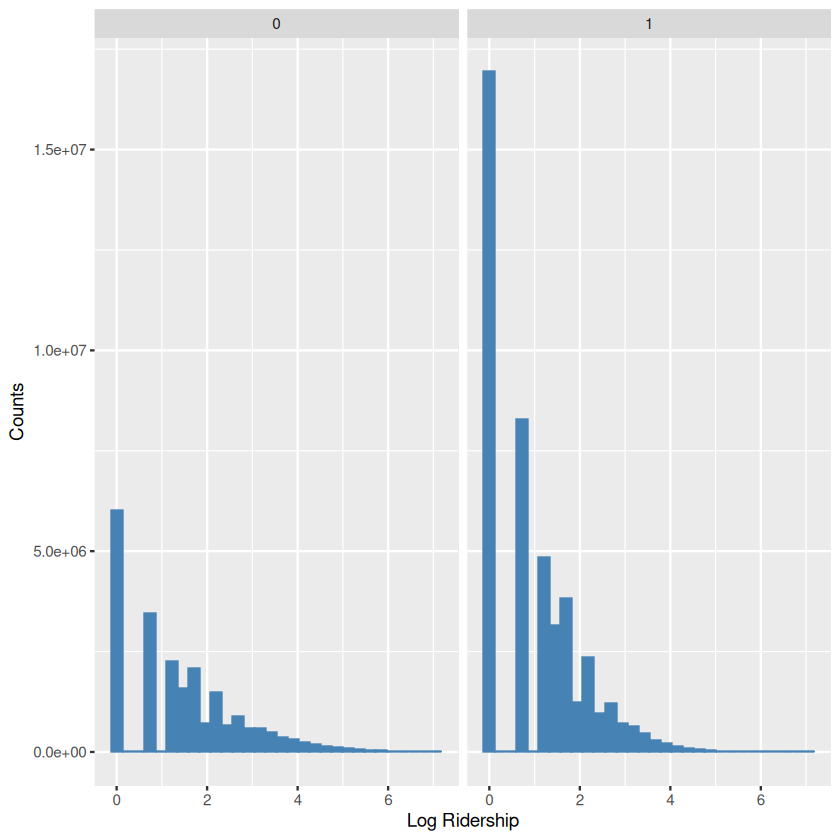

In [11]:
od_data |> 
    ggplot(aes(x = log_ridership)) + 
        geom_histogram(bins = 30, color = "steelblue", fill = "steelblue") + 
        labs(x = "Log Ridership",
            y = "Counts") + 
        facet_wrap(~ post_covid)

I want to check, now that I've added some additional features, what is the size of this data object?

In [12]:
format(object.size(od_data), units = "Gb")

[1] "4 Gb"

This is problematic. It's much larger now. We should probably downgrade the scope. I'm going to start by filtering out 2020 and 2021 from the data as it doesn't represent regular ridership patterns. We can also fiter out hours when BART is not in service.

I'm curious, what is the distribution of ridership when the hour column is between 1:00 - 5:00 AM?

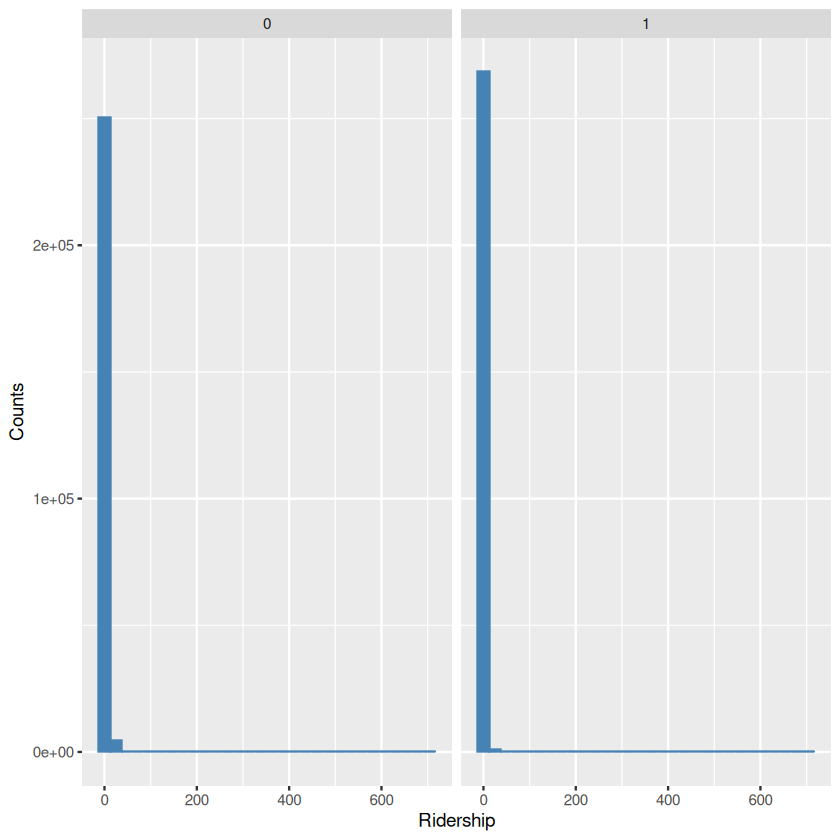

In [13]:
od_data |> 
    filter(hour %in% c(1, 2, 3, 4)) |>
    # ridership here should be replaced with hour
    # this is a typo
    # I can't run this code on my personal computer to fix it
    # I will fix it next time I have access to the scf
    ggplot(aes(x = ridership)) + 
        geom_histogram(bins = 30, color = "steelblue", fill = "steelblue") + 
        labs(x = "Ridership",
            y = "Counts") + 
        facet_wrap(~ post_covid)

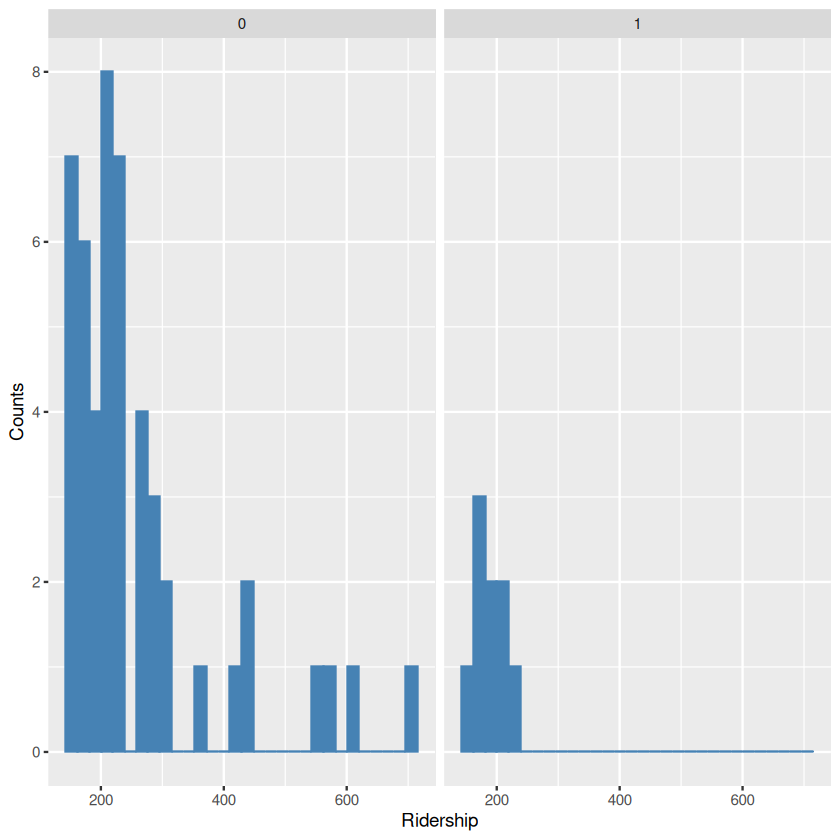

In [23]:
od_data |> 
    filter(hour %in% c(1, 2, 3, 4)) |>
    filter(ridership > 150) |>
    ggplot(aes(x = ridership)) + 
        geom_histogram(bins = 30, color = "steelblue", fill = "steelblue") + 
        labs(x = "Ridership",
            y = "Counts") + 
        facet_wrap(~ post_covid)

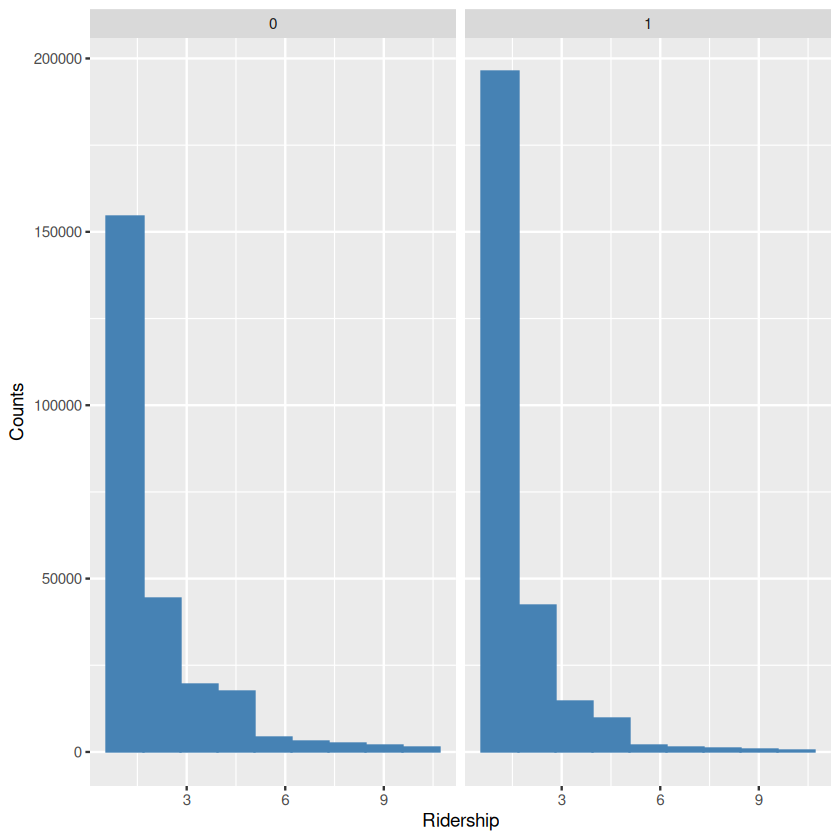

In [27]:
od_data |> 
    filter(hour %in% c(1, 2, 3, 4)) |>
    filter(ridership <= 10) |>
    ggplot(aes(x = ridership)) + 
        geom_histogram(bins = 9, color = "steelblue", fill = "steelblue") + 
        labs(x = "Ridership",
            y = "Counts") + 
        facet_wrap(~ post_covid)

In [14]:
od_data_filtered <- od_data |>
                filter(!(year(date) %in% c(2020, 2021)) & 
                        !(hour %in% c(1, 2, 3, 4)))

`summarise()` has grouped output by 'day'. You can override using the `.groups`
argument.


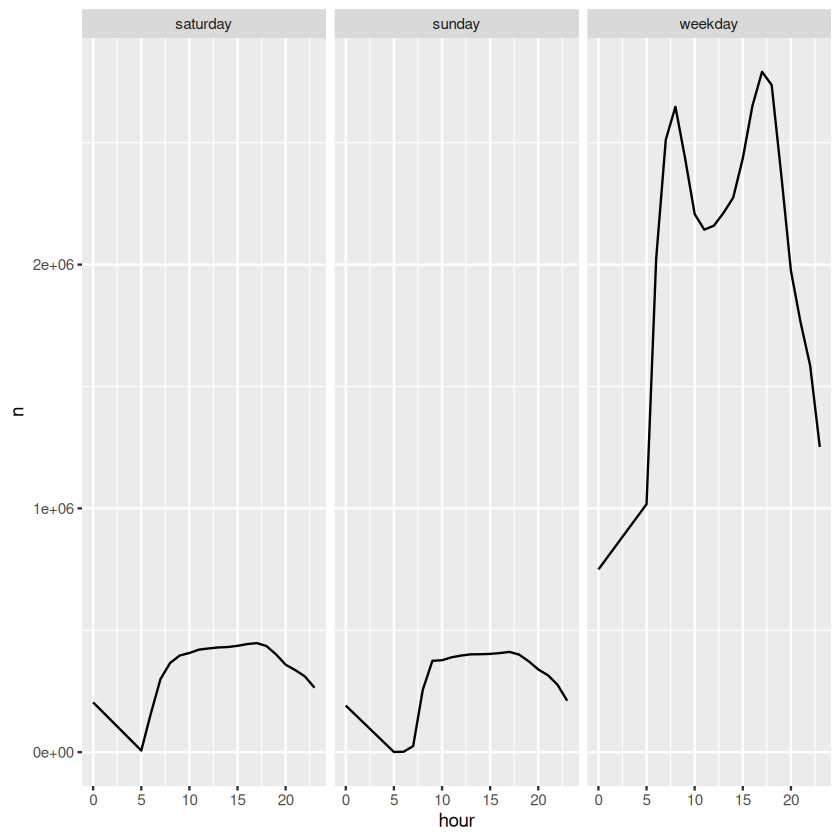

In [15]:
od_data_filtered |>
    group_by(day, hour) |>
    summarize(n = n()) |>
    ggplot(aes(x = hour)) + 
        geom_line(aes(y = n)) + 
        facet_wrap(~ day)

Let's see the size now

In [16]:
format(object.size(od_data_filtered), units = "GB")

[1] "3.3 Gb"

My last comment before I stop is that there are different service hours on weekdays, saturdays, and sundays, so we will need to apply different filtering rules in the future. Additionally, I'm not sure if the service hours have stayed the same from 2018-2025.

# Filtering Data

I say we still remove the during-covid data, as it's not representative of regular ridership. Second, we should filter the data based on relevant hours. For the 2025 data, the regular schedule is below

| Day | Hours |
|-----|-------|
| Weekday | 5:00 AM - 12:00 AM |
| Saturday | 6:00 AM - 12:00 AM |
| Sunday | 8:00 AM - 12:00 AM |

Note that, while the last train is sent out at 12:00 AM, there are still trains in service during the 12:00 - 2:00 AM hours. The latest train I could find ends it's run at Berryessa at around 2:00 AM. While these are still interesting ridership numbers, they are not that relevant. Time and resources would be better spent analysing the commute hours and between.

`summarise()` has grouped output by 'year', 'day'. You can override using the
`.groups` argument.


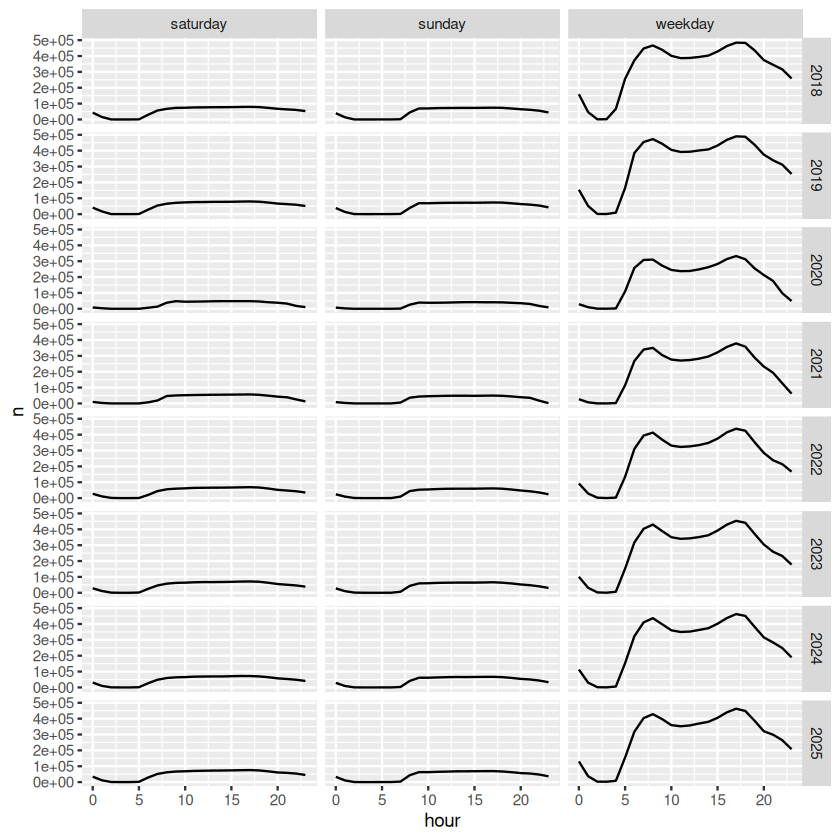

In [17]:
od_data |>
    mutate(year = year(date)) |>
    group_by(year, day, hour) |>
    summarize(n = n()) |>
    ggplot(aes(x = hour)) + 
        geom_line(aes(y = n)) + 
        facet_grid(rows = vars(year), cols = vars(day))

`summarise()` has grouped output by 'year', 'day'. You can override using the
`.groups` argument.
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_line()`).”


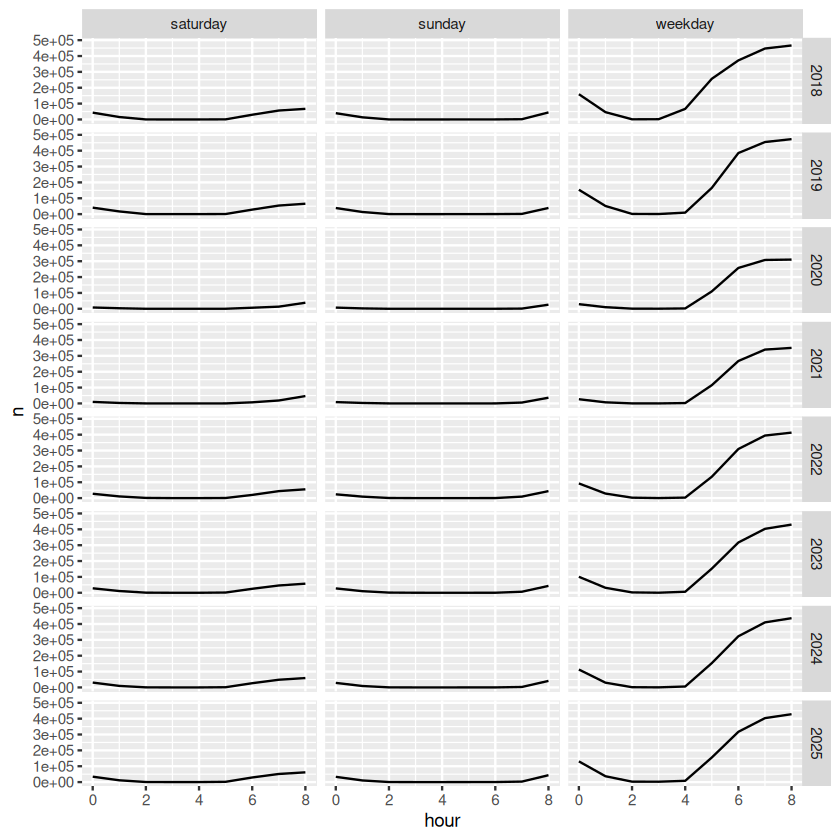

In [18]:
od_data |>
    mutate(year = year(date)) |>
    group_by(year, day, hour) |>
    summarize(n = n()) |>
    ggplot(aes(x = hour)) + 
        geom_line(aes(y = n)) + 
        xlim(0, 8) + 
        facet_grid(rows = vars(year), cols = vars(day))

Let's see what happens if we limit the data to only weekday rides, and then only destination data instead of OD pairs. If we're interested in commuting data, then anyone who leaves from a station will return to it at a later time of day. With the exception of SFO and Oakland Airport

In [19]:
rm(od_data_filtered)

In [20]:
dest_weekday <- od_data |>
                    filter(day == "weekday") |>
                    group_by(date, hour, destination) |>
                    summarise(ridership = sum(ridership))

head(dest_weekday)

`summarise()` has grouped output by 'date', 'hour'. You can override using the
`.groups` argument.


date,hour,destination,ridership
<date>,<dbl>,<chr>,<dbl>
2018-01-01,0,12TH,133
2018-01-01,0,16TH,75
2018-01-01,0,19TH,64
2018-01-01,0,24TH,87
2018-01-01,0,ASHB,23
2018-01-01,0,BALB,116


In [21]:
format(object.size(dest_weekday), units = "GB")

[1] "0.1 Gb"

In [22]:
dim(dest_weekday)[1]

[1] 2110790

That's crazy, it's so much smaller.